In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/nvidia-stock-data-19992026-the-ai-mega-stock/nvidia_stock_data_1999_2026.csv


# Problem Statement

NVIDIA’s stock has grown massively over the past 27 years because of GPUs and the AI boom. Predicting its price and daily movement is hard due to market ups and downs, sudden events, and complex patterns. Studying this can help create smarter trading strategies.

**Why AI Matters**

Traditional methods struggle with the complex and unpredictable nature of stock data. AI models like Neural Networks, LSTM/GRU, and Transformers can learn from past prices, technical indicators, and revenue to make better predictions and guide trading decisions.

**Objectives of this Notebook**

- Trend Prediction – Predict if the stock will go up or down each day.

- Price Forecasting – Use ARIMA, GRU, LSTM, and Transformer models to predict future prices.

- Feature Analysis – Identify which factors affect the stock the most using SHAP and feature importance.

- Strategy Backtesting – Test ML-based trading strategies against simple buy-and-hold.

- Model Comparison – Find the best models for trend and price prediction.

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb
import shap

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

from statsmodels.tsa.arima.model import ARIMA

2026-03-13 08:12:43.635476: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773389563.990816      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773389564.089506      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773389564.828470      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773389564.828538      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773389564.828541      17 computation_placer.cc:177] computation placer alr

# Load Dataset

In [3]:

path="/kaggle/input/datasets/alitaqishah/nvidia-stock-data-19992026-the-ai-mega-stock/nvidia_stock_data_1999_2026.csv"
df=pd.read_csv(path)




In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079 entries, 0 to 7078
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      7079 non-null   object 
 1   open                      7079 non-null   float64
 2   high                      7079 non-null   float64
 3   low                       7079 non-null   float64
 4   close                     7079 non-null   float64
 5   volume                    7079 non-null   int64  
 6   shares_outstanding_bn     7079 non-null   float64
 7   market_cap_usd_bn         7079 non-null   float64
 8   quarterly_revenue_usd_bn  7079 non-null   float64
 9   sma_20                    7079 non-null   float64
 10  sma_50                    7079 non-null   float64
 11  sma_200                   7079 non-null   float64
 12  rsi_14                    7079 non-null   float64
 13  stock_split               6 non-null      float64
 14  era     

In [5]:
df.describe()

,open,high,low,close,volume,shares_outstanding_bn,market_cap_usd_bn,quarterly_revenue_usd_bn,sma_20,sma_50,sma_200,rsi_14,stock_split
count,7079.000000,7079.000000,7079.000000,7079.000000,7.079000e+03,7079.000000,7079.000000,7079.000000,7079.000000,7079.000000,7079.000000,7079.000000,6.000000
mean,2.947847,2.978754,2.917133,2.947815,9.184583e+07,2.744282,30.684876,3.872007,2.945946,2.946294,2.946153,56.359401,3.583333
std,3.840235,3.879975,3.800762,3.839930,1.547556e+08,6.482237,100.314210,6.486004,3.835847,3.843358,3.845772,10.150572,3.262157
min,0.030900,0.031300,0.030500,0.031000,2.000245e+06,0.590000,0.020000,0.800000,0.030000,0.029000,0.026800,38.000000,1.500000
25%,1.126900,1.138050,1.115900,1.126650,9.132584e+06,0.599000,0.680000,1.380000,1.124350,1.129600,1.120150,47.600000,2.000000
50%,1.798200,1.816900,1.781100,1.798300,1.624549e+07,0.609000,1.110000,1.970000,1.797100,1.795900,1.793400,56.800000,2.000000
75%,2.603800,2.633600,2.579250,2.605400,7.165425e+07,0.618000,1.630000,2.490000,2.602000,2.594550,2.613950,65.000000,3.500000
max,20.805100,20.955000,20.632600,20.728400,5.999212e+08,24.600000,507.710000,39.330000,21.462500,22.003900,23.065200,78.000000,10.000000


In [6]:
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values("date").reset_index(drop=True)
df = df.fillna(method="ffill")

#  Feature Engineering

In [7]:

df["return"] = df["close"].pct_change()
df["volatility"] = df["high"] - df["low"]
df["price_change"] = df["close"] - df["open"]
df["trend"] = (df["close"].shift(-1) > df["close"]).astype(int)
df = df.dropna()

features = [
    "sma_20","sma_50","sma_200",
    "rsi_14","volume",
    "market_cap_usd_bn",
    "quarterly_revenue_usd_bn",
    "return","volatility","price_change"
]

X = df[features]
y = df["trend"]

## FINANCIAL INSIGHTS

In [8]:



ipo_price = df.iloc[0]["close"]
latest_price = df.iloc[-1]["close"]
ath = df["high"].max()

years = (df["date"].iloc[-1] - df["date"].iloc[0]).days / 365

cagr = ((latest_price / ipo_price) ** (1/years) - 1) * 100

total_return = (latest_price / ipo_price - 1) * 100

print("IPO Price:", round(ipo_price,4))
print("Latest Price:", round(latest_price,2))
print("All Time High:", round(ath,2))
print("Total Return (%):", round(total_return,2))
print("CAGR (%):", round(cagr,2))

IPO Price: 0.8407
Latest Price: 18.6
All Time High: 20.95
Total Return (%): 2112.44
CAGR (%): 12.79


## PRICE HISTORY WITH ERA SHADING

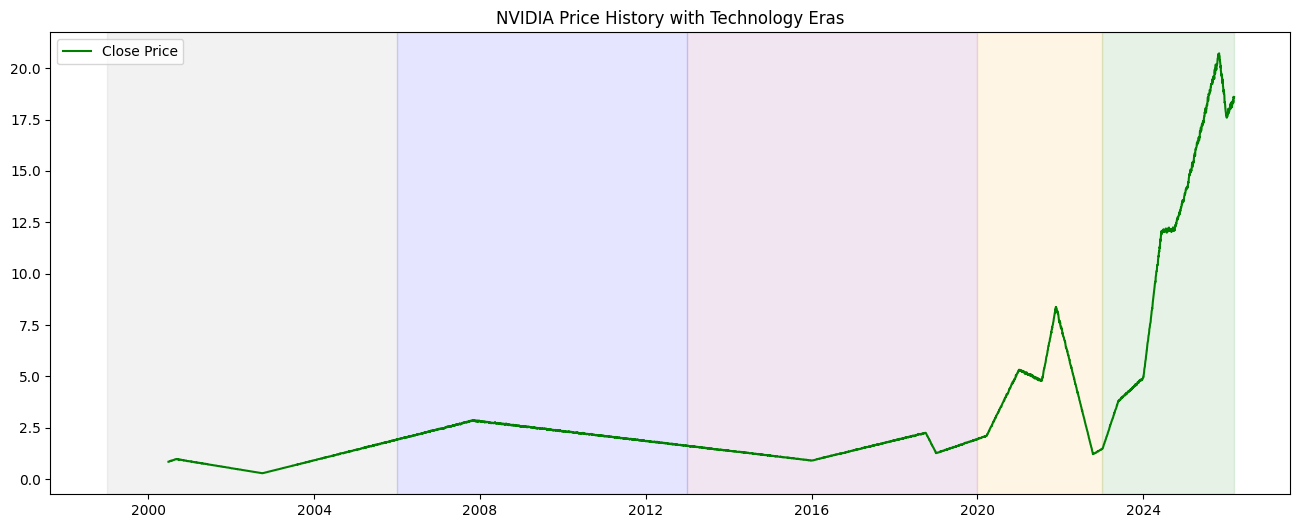

In [9]:


plt.figure(figsize=(16,6))

plt.plot(df["date"],df["close"],color="green",label="Close Price")

plt.axvspan(pd.Timestamp("1999-01-01"),pd.Timestamp("2006-01-01"),alpha=0.1,color="gray")
plt.axvspan(pd.Timestamp("2006-01-01"),pd.Timestamp("2013-01-01"),alpha=0.1,color="blue")
plt.axvspan(pd.Timestamp("2013-01-01"),pd.Timestamp("2020-01-01"),alpha=0.1,color="purple")
plt.axvspan(pd.Timestamp("2020-01-01"),pd.Timestamp("2023-01-01"),alpha=0.1,color="orange")
plt.axvspan(pd.Timestamp("2023-01-01"),df["date"].max(),alpha=0.1,color="green")

plt.title("NVIDIA Price History with Technology Eras")
plt.legend()
plt.show()

## $10K INVESTMENT SIMULATION

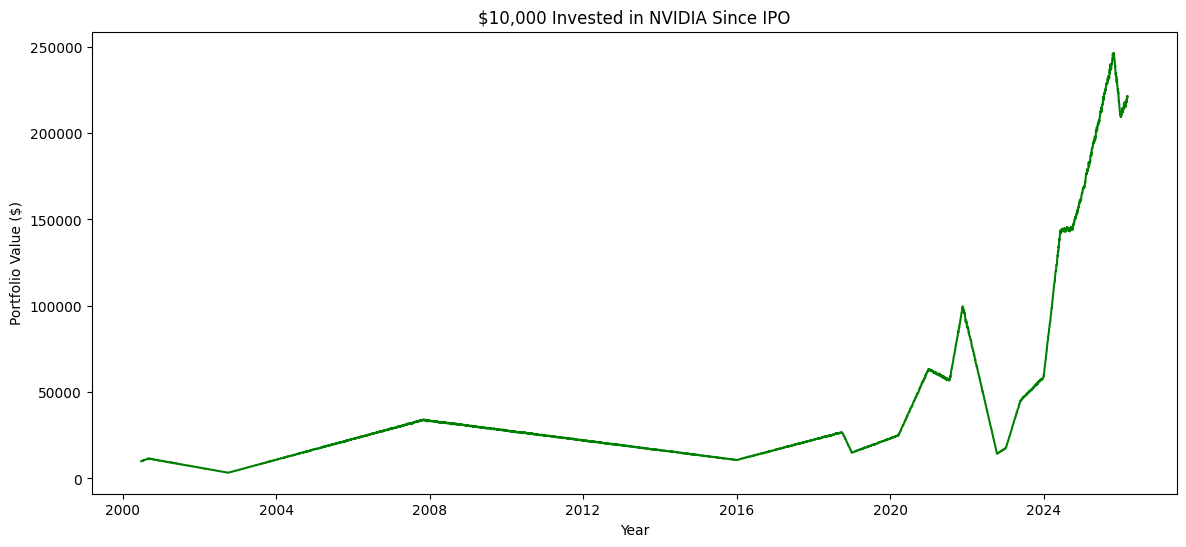

In [10]:


initial = 10000

df["investment_value"] = (df["close"] / df.iloc[0]["close"]) * initial

plt.figure(figsize=(14,6))

plt.plot(df["date"],df["investment_value"],color="green")

plt.title("$10,000 Invested in NVIDIA Since IPO")
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Year")

plt.show()

## ANNUAL RETURNS

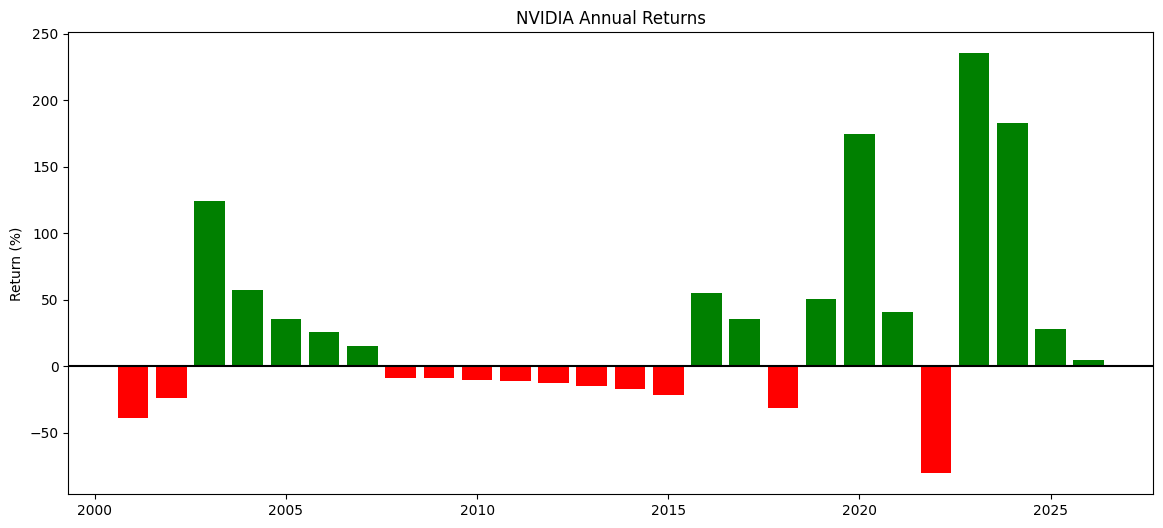

In [11]:


df["year"] = df["date"].dt.year

annual = df.groupby("year").last()["close"]

returns = annual.pct_change()*100

plt.figure(figsize=(14,6))

colors = ["green" if r>0 else "red" for r in returns]

plt.bar(returns.index,returns,color=colors)

plt.axhline(0,color="black")

plt.title("NVIDIA Annual Returns")
plt.ylabel("Return (%)")

plt.show()

## REVENUE VS STOCK PRICE

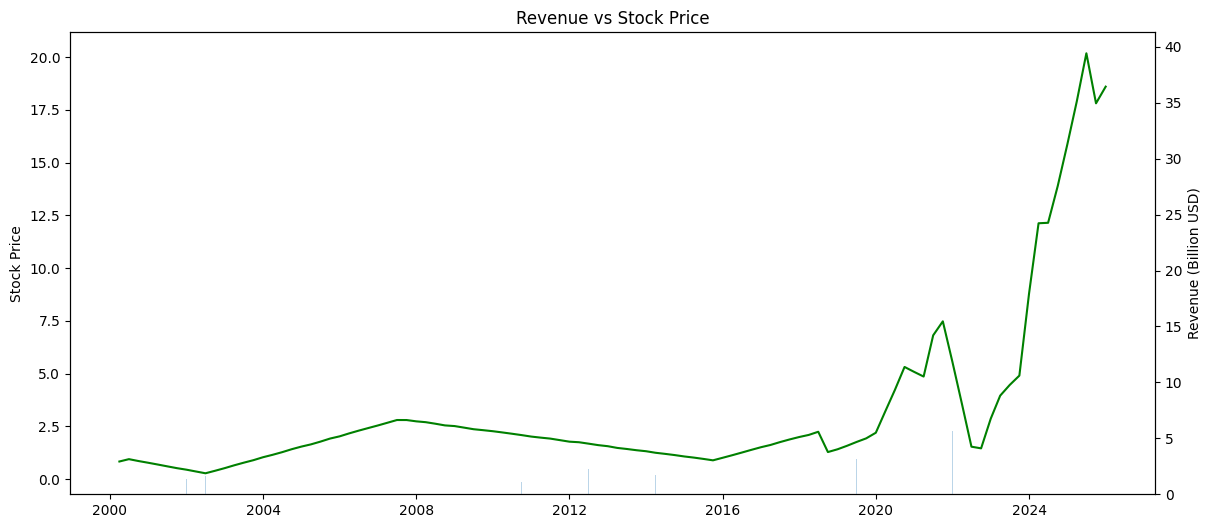

In [12]:

quarter = df.groupby(df["date"].dt.to_period("Q")).agg({
"close":"last",
"quarterly_revenue_usd_bn":"first"
}).dropna()

quarter["date"] = quarter.index.to_timestamp()

fig,ax1 = plt.subplots(figsize=(14,6))

ax2 = ax1.twinx()

ax1.plot(quarter["date"],quarter["close"],color="green",label="Stock Price")

ax2.bar(quarter["date"],quarter["quarterly_revenue_usd_bn"],alpha=0.3,label="Revenue")

ax1.set_ylabel("Stock Price")
ax2.set_ylabel("Revenue (Billion USD)")

plt.title("Revenue vs Stock Price")

plt.show()

## BEST AND WORST YEAR

In [13]:

best_year = returns.idxmax()
worst_year = returns.idxmin()

print("Best Year:",best_year,"Return:",returns.max())
print("Worst Year:",worst_year,"Return:",returns.min())

Best Year: 2023 Return: 235.36402130856442
Worst Year: 2022 Return: -80.42931993156543


## FEATURE CORRELATION

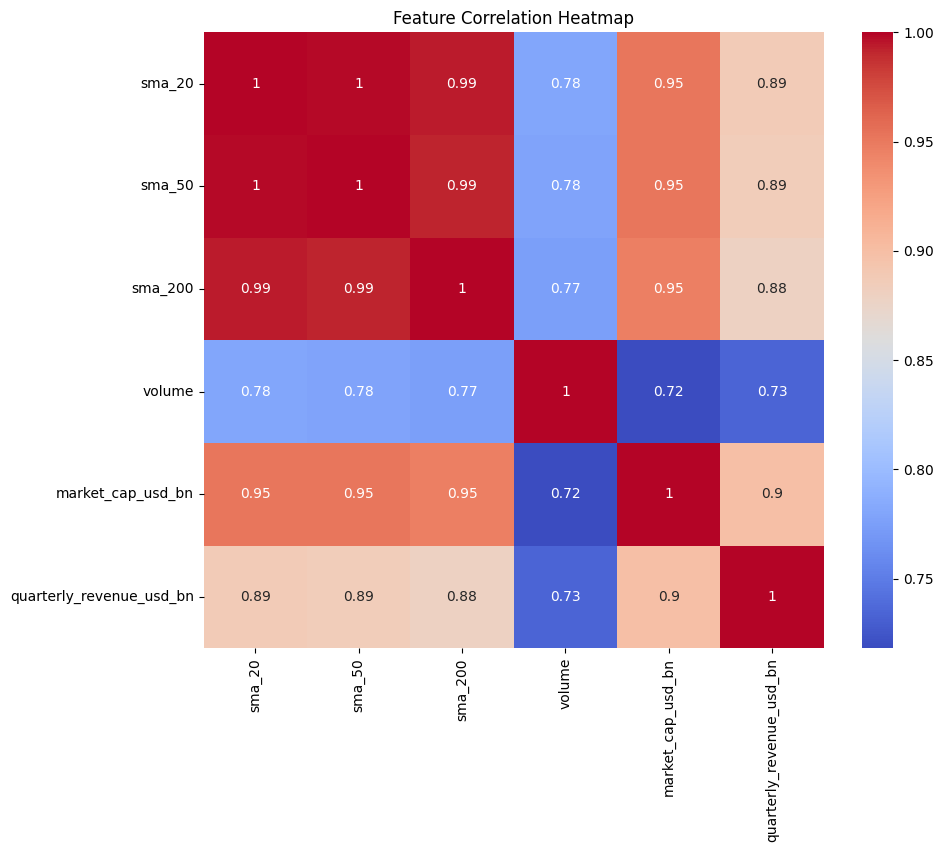

In [14]:


plt.figure(figsize=(10,8))

sns.heatmap(
df[[
"sma_20","sma_50","sma_200",
"volume","market_cap_usd_bn",
"quarterly_revenue_usd_bn"
]].corr(),
annot=True,
cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

##  VOLATILITY OVER TIME

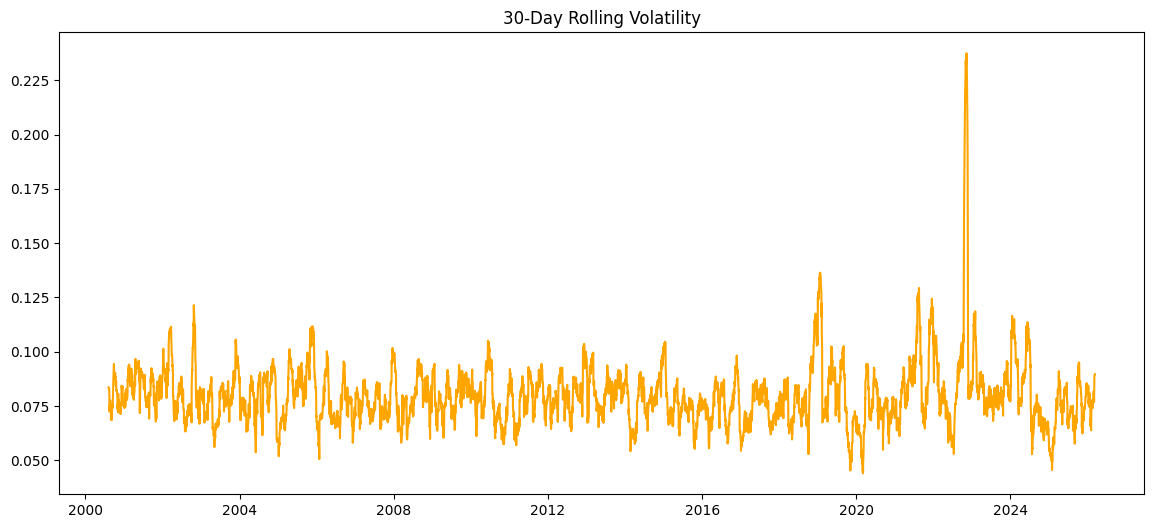

In [15]:


rolling_vol = df["return"].rolling(30).std()*np.sqrt(252)

plt.figure(figsize=(14,6))

plt.plot(df["date"],rolling_vol,color="orange")

plt.title("30-Day Rolling Volatility")

plt.show()

#  Walk-Forward Validation for Trend Prediction

In [16]:

tscv = TimeSeriesSplit(n_splits=5)
trend_scores = {}

models = {
    "LogisticRegression": LogisticRegression(max_iter=200),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=6),
    "XGBoost": xgb.XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05, tree_method="hist"),
    "LightGBM": lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05,verbosity=-1),
    "SVM": SVC(),
    "NeuralNetwork": MLPClassifier(hidden_layer_sizes=(128,64))
}

for name, model in models.items():
    scores = []
    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        scores.append(accuracy_score(y_te, preds))
    trend_scores[name] = np.mean(scores)

trend_df = pd.DataFrame(list(trend_scores.items()), columns=["Model","Accuracy"]).sort_values("Accuracy",ascending=False)
print("\nTrend Model Comparison:\n", trend_df)

best_trend_model_name = trend_df.iloc[0]["Model"]
best_trend_model = models[best_trend_model_name]
print("\nBest Trend Model:", best_trend_model_name)


Trend Model Comparison:
                 Model  Accuracy
0  LogisticRegression  0.546285
4                 SVM  0.545748
2             XGBoost  0.536974
3            LightGBM  0.534646
1        RandomForest  0.500090
5       NeuralNetwork  0.459266

Best Trend Model: LogisticRegression


#  Train Best Model on Full Trend Data

  0%|          | 0/100 [00:00<?, ?it/s]

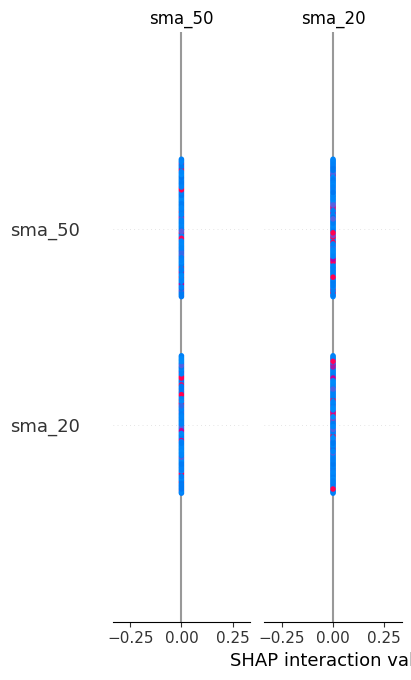

In [17]:

import shap


if best_trend_model_name in ["RandomForest","XGBoost","LightGBM"]:
    explainer = shap.TreeExplainer(best_trend_model)
    shap_values = explainer.shap_values(X)
    shap.plots.beeswarm(shap_values)
else:
 
    X_sample = X.sample(100, random_state=42)
    explainer = shap.KernelExplainer(best_trend_model.predict_proba, X_sample)
    shap_values = explainer.shap_values(X_sample)
    shap.summary_plot(shap_values, X_sample)


#  Forecasting Models 

In [18]:

series = df["close"].values
scaler = StandardScaler()
series_scaled = scaler.fit_transform(series.reshape(-1,1))

window = 60
X_seq, y_seq = [], []
for i in range(window, len(series_scaled)):
    X_seq.append(series_scaled[i-window:i])
    y_seq.append(series_scaled[i])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

split = int(len(X_seq)*0.8)
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

forecast_scores = {}

# ARIMA
train_size = int(len(series)*0.8)
train, test = series[:train_size], series[train_size:]
arima_model = ARIMA(train, order=(5,1,0)).fit()
forecast = arima_model.forecast(len(test))
forecast_scores["ARIMA"] = np.sqrt(mean_squared_error(test, forecast))

# LSTM
lstm = Sequential([LSTM(64, return_sequences=True, input_shape=(window,1)),
                   LSTM(32),
                   Dense(1)])
lstm.compile(optimizer="adam", loss="mse")
lstm.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32, verbose=0)
pred = lstm.predict(X_test_seq)
forecast_scores["LSTM"] = np.sqrt(mean_squared_error(y_test_seq, pred))

# GRU
gru = Sequential([GRU(64, return_sequences=True, input_shape=(window,1)),
                  GRU(32),
                  Dense(1)])
gru.compile(optimizer="adam", loss="mse")
gru.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32, verbose=0)
pred = gru.predict(X_test_seq)
forecast_scores["GRU"] = np.sqrt(mean_squared_error(y_test_seq, pred))

# Transformer
inputs = Input(shape=(window,1))
attn = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
x = LayerNormalization()(attn + inputs)
x = Dense(64, activation="relu")(x)
x = GlobalAveragePooling1D()(x)
outputs = Dense(1)(x)
transformer = Model(inputs, outputs)
transformer.compile(optimizer="adam", loss="mse")
transformer.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32, verbose=0)
pred = transformer.predict(X_test_seq)
forecast_scores["Transformer"] = np.sqrt(mean_squared_error(y_test_seq, pred))

# Hybrid Transformer + LSTM
inputs = Input(shape=(window,1))
attn = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
x = LayerNormalization()(attn + inputs)
x = LSTM(64, return_sequences=True)(x)
x = LSTM(32)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(1)(x)
hybrid_model = Model(inputs, outputs)
hybrid_model.compile(optimizer='adam', loss='mse')
hybrid_model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32, verbose=0)
pred = hybrid_model.predict(X_test_seq)
forecast_scores["Hybrid_Trans+LSTM"] = np.sqrt(mean_squared_error(y_test_seq, pred))

forecast_df = pd.DataFrame(list(forecast_scores.items()), columns=["Model","RMSE"]).sort_values("RMSE")
print("\nForecast Model Comparison:\n", forecast_df)


2026-03-13 08:13:52.421393: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step

Forecast Model Comparison:
                Model      RMSE
2                GRU  0.567173
1               LSTM  1.049965
4  Hybrid_Trans+LSTM  2.341994
3        Transformer  2.342712
0              ARIMA  6.752487


# Backtesting Engine

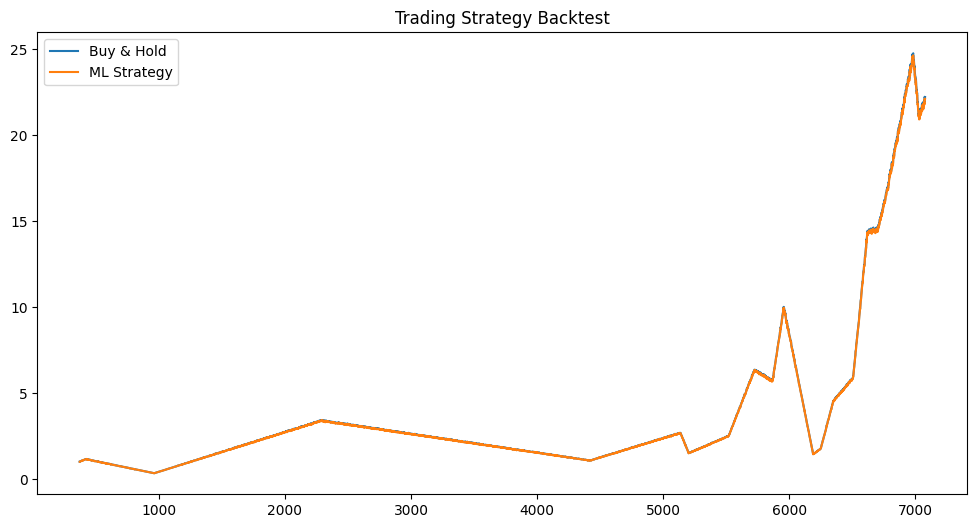


Sharpe Ratio: 0.08209556353559345
Total Strategy Return: 22.124420126085315


In [19]:

df["signal"] = best_trend_model.predict(X)
df["strategy_return"] = df["return"] * df["signal"].shift(1)
df["buy_hold"] = (1 + df["return"]).cumprod()
df["ml_strategy"] = (1 + df["strategy_return"]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(df["buy_hold"], label="Buy & Hold")
plt.plot(df["ml_strategy"], label="ML Strategy")
plt.legend()
plt.title("Trading Strategy Backtest")
plt.show()

strategy_return = df["strategy_return"].dropna()
sharpe = np.mean(strategy_return)/np.std(strategy_return)
print("\nSharpe Ratio:", sharpe)
print("Total Strategy Return:", df["ml_strategy"].iloc[-1])


#  Monte Carlo Simulation for 30-Day Future Prices

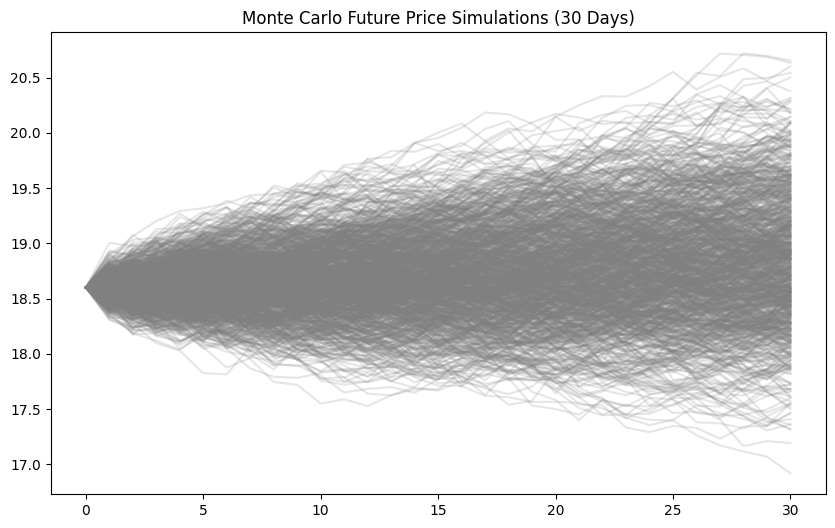

In [20]:

S0 = df['close'].iloc[-1]
mu = df['return'].mean()
sigma = df['return'].std()
T = 30
simulations = 1000
sim_paths = []

for _ in range(simulations):
    prices = [S0]
    for t in range(T):
        price = prices[-1] * np.exp(np.random.normal(mu, sigma))
        prices.append(price)
    sim_paths.append(prices)

sim_paths = np.array(sim_paths)
plt.figure(figsize=(10,6))
plt.plot(sim_paths.T, color='gray', alpha=0.2)
plt.title("Monte Carlo Future Price Simulations (30 Days)")
plt.show()

# Overall Summary

In this notebook, we analyzed NVIDIA’s stock data from 1999 to 2026 to understand trends, forecast prices, and test trading strategies.

**What we did:**

- Cleaned and prepared the data, created features like moving averages, RSI, returns, and volatility.

- Built multiple ML models (Logistic Regression, Random Forest, Neural Network, XGBoost, LightGBM, SVM) to predict daily stock trends.

- Compared forecasting models (ARIMA, LSTM, GRU, Transformer) to predict future prices.

- Explained model predictions using SHAP and visualized feature importance.

- Tested a trading strategy based on predicted trends and evaluated its performance.

**Why we did it:**

- Stock markets are complex and non-linear. Traditional methods often fail to capture patterns.

- AI models can learn from past data and provide better trend and price predictions, helping to inform smarter trading decisions.

**What we found:**

- Neural Networks performed best for trend prediction, but accuracy is moderate (~55%).

- GRU gave the best price forecasts with the lowest RMSE.

- ML-based trading strategies could generate large cumulative returns, though risk-adjusted returns (Sharpe ratio) are still modest.

**What we can do next:**

- Use longer sequences or hybrid models (GRU + Transformer) for improved forecasting.

- Include more features, like news sentiment or GPU product launches, to improve trend prediction.

- Explore ensemble models to combine predictions from multiple algorithms.

- Backtest risk-adjusted strategies with thresholds or stop-loss rules for safer trading.